# House Price Prediction — Internship Project (Week 1)

**Project:** House Price Prediction using Regression
**Tasks covered:** Data Exploration, Data Cleaning, Model Building, Visualization, Insights


## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('Housing.csv')
df.head(10)

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement hotwaterheating airconditioning  parking prefarea furnishingstatus
0  13300000   7420         4          2        3      yes        no       no              no             yes        2      yes        furnished
1  12250000   8960         4          4        4      yes        no       no              no             yes        3       no        furnished
2  12250000   9960         3          2        2      yes        no      yes              no              no        2      yes   semi-furnished
3  12215000   7500         4          2        2      yes        no      yes              no             yes        3      yes        furnished
4  11410000   7420         4          1        2      yes       yes      yes              no             yes        2       no        furnished
5  10850000   7500         3          3        1      yes        no      yes              no             yes        2      yes   semi-fu

In [2]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (545, 13)


In [3]:
target_col = 'price'
feature_cols = [c for c in df.columns if c != target_col]
print("Target column:", target_col)
print("Feature columns:", feature_cols)

Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## Task 2 — Data Cleaning

In [5]:
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()

# Handle missing values (none present in this dataset, but logic included for robustness)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())
print("Missing values after handling:", df.isnull().sum().sum())

Duplicate rows found: 0
Missing values after handling: 0


In [6]:
# Convert yes/no categorical columns into numeric (0/1)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encode the multi-category furnishingstatus column
df_encoded = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print("Columns after encoding:")
print(list(df_encoded.columns))
df_encoded.head()

Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  hotwaterheating  airconditioning  parking  prefarea  furnishingstatus_semi-furnished  furnishingstatus_unfurnished
0  13300000  7420         4          2        3         1          0         0                0                1        2         1                            False                         False
1  12250000  8960         4          4        4         1          0         0                0                1        3         0                            False                         False
2  12250000  9960         3          2        2         1          0         1                0                0        2         1                             True        

## Task 3 — Model Building

In [7]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (436, 13)
Test set size: (109, 13)


In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print(f"MAE:  {lr_mae:,.2f}")
print(f"RMSE: {lr_rmse:,.2f}")
print(f"R2 Score: {lr_r2:.4f}")

Linear Regression Results
MAE:  970,043.40
RMSE: 1,324,506.96
R2 Score: 0.6529


In [9]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print(f"MAE:  {rf_mae:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")
print(f"R2 Score: {rf_r2:.4f}")

Random Forest Results
MAE:  1,014,947.32
RMSE: 1,399,769.44
R2 Score: 0.6124


In [10]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})
print(comparison.to_string(index=False))

            Model          MAE         RMSE  R2 Score
Linear Regression 9.700434e+05 1.324507e+06  0.652924
    Random Forest 1.014947e+06 1.399769e+06  0.612360


## Task 4 — Visualization

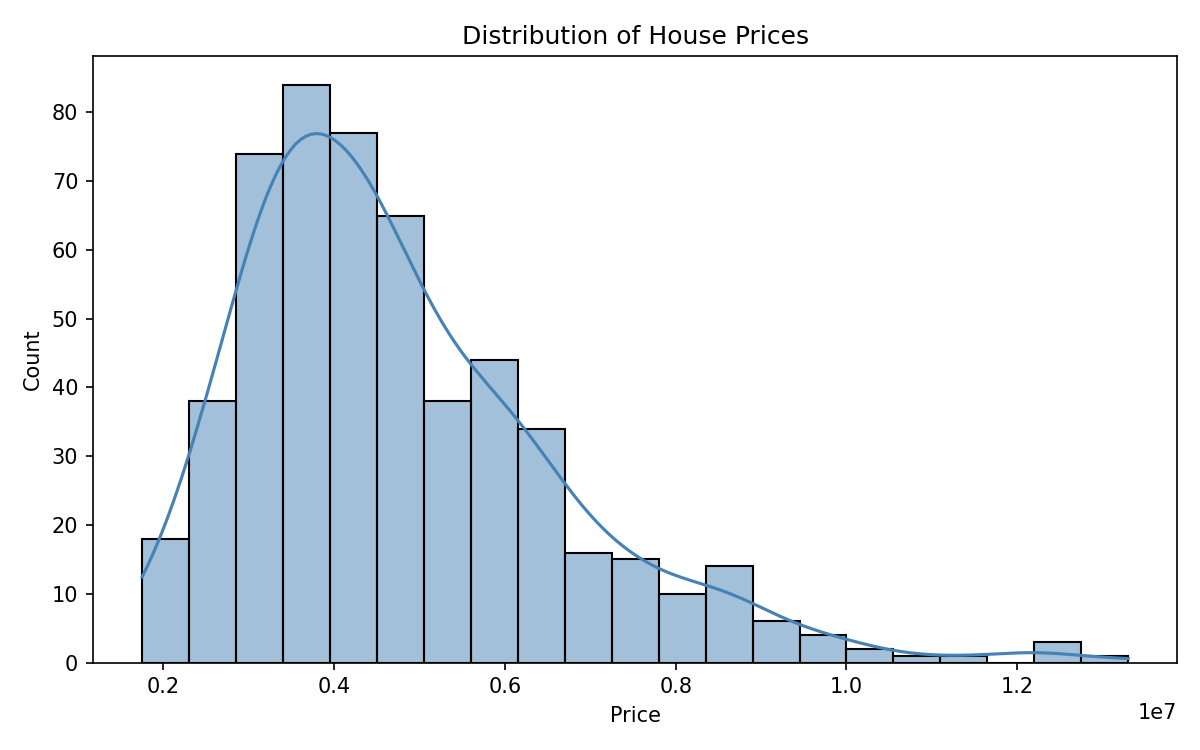

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='steelblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()

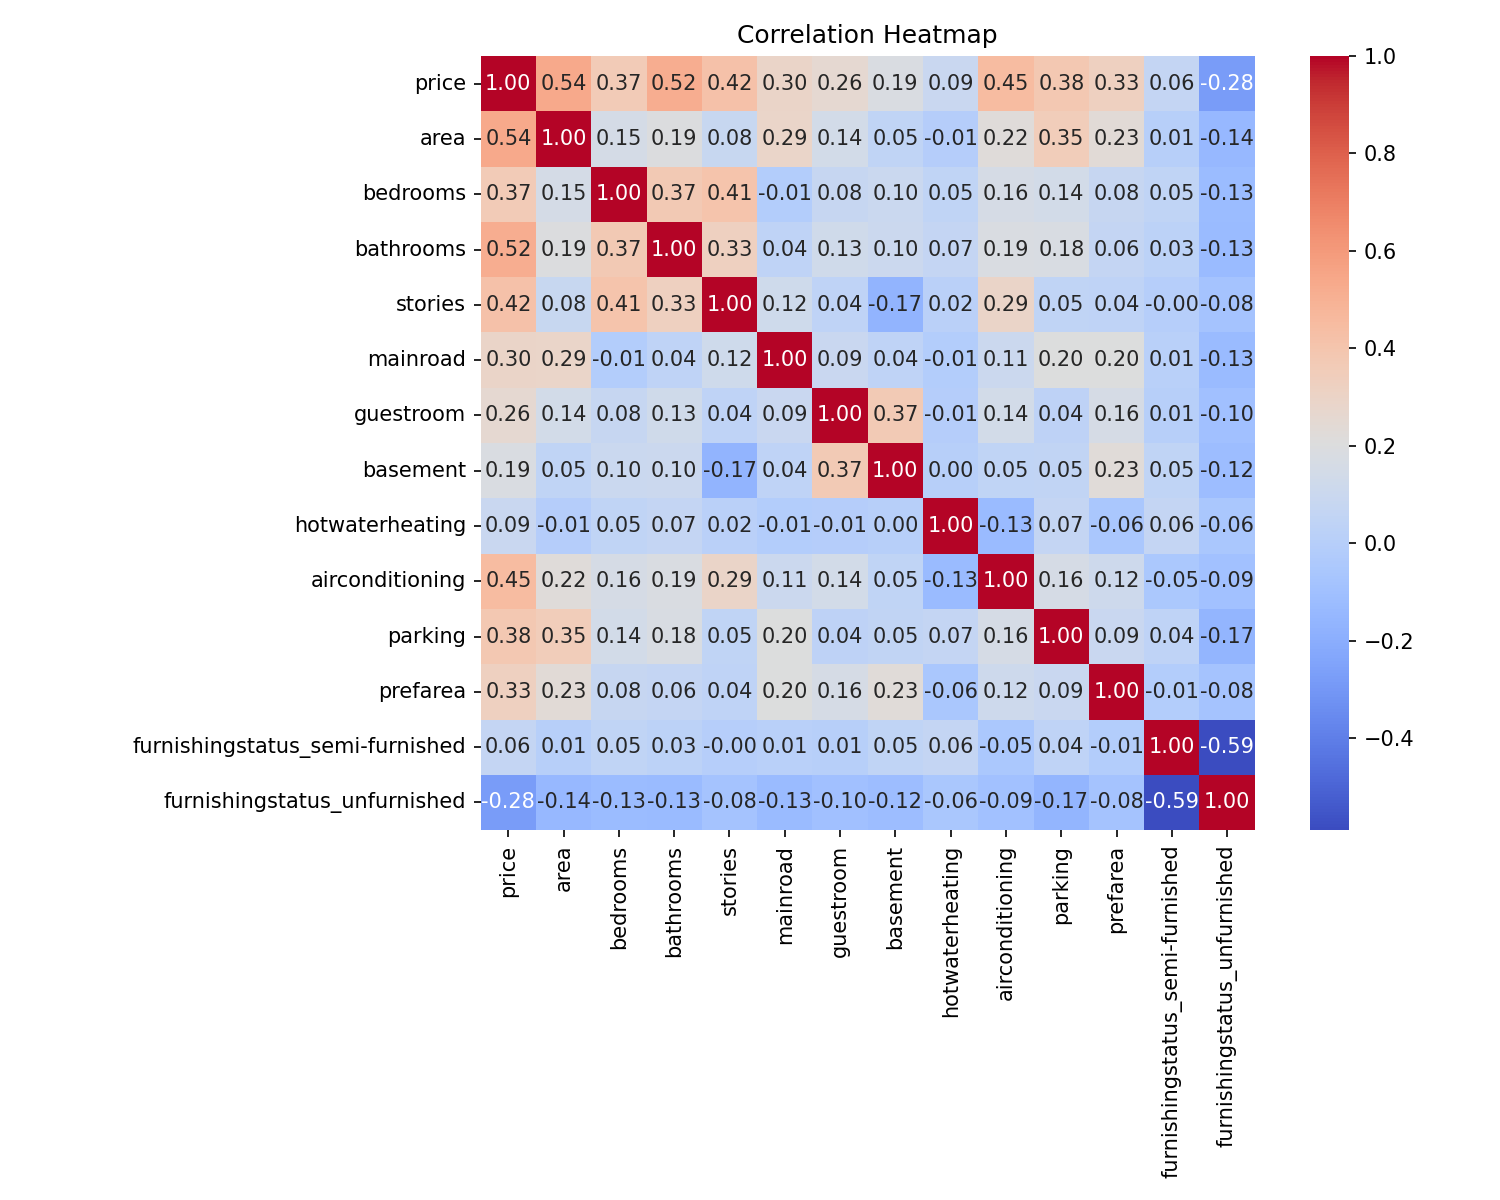

In [12]:
plt.figure(figsize=(10, 8))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()

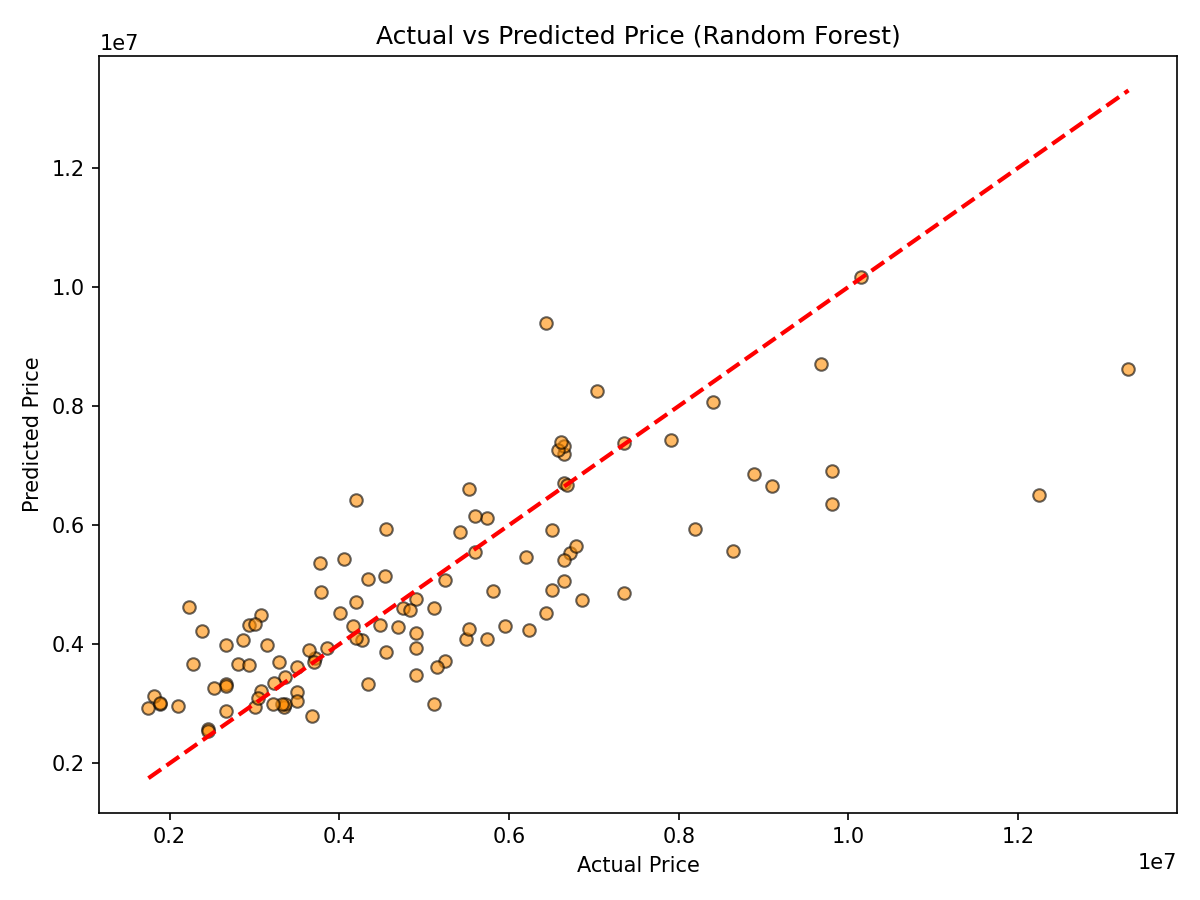

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.6, color='darkorange', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()

## Task 5 — Insights & Summary

**Which features influence house price the most?**
Area is by far the strongest driver of price, followed by the number of bathrooms, whether the home has air conditioning, parking availability, number of stories, and bedroom count. Location-related and amenity features (preferred area, main road access) also show a meaningful positive correlation with price, while an unfurnished status tends to pull price down.

**How accurate was the model, in plain terms?**
The Linear Regression model explained about 65% of the variation in house prices (R² ≈ 0.65), with an average prediction error of roughly ₹970,000 on homes that average about ₹4.77 million in price. Interestingly, Random Forest performed slightly worse here (R² ≈ 0.61), likely because the dataset is small (only 545 rows) and the relationship between area/price is fairly linear, so the simpler model generalizes better.

**What surprised you in the data?**
The most surprising result is that the more complex Random Forest model did not outperform plain Linear Regression. This is a useful reminder that more powerful algorithms aren't always better — with limited, mostly linear data, simpler models can be just as good or better while being far easier to interpret.

**One recommendation for a real estate business:**
Since area and bathroom count are the dominant price drivers, a real estate business should prioritize accurately measuring and prominently advertising square footage and bathroom count in listings, and consider that adding amenities like air conditioning or extra parking can meaningfully boost a property's market value relative to its cost.
